In [1]:
## PRICE ELASTICITIES BY ITEM FROM LightGBM

- LightGBM cannot give a coefficient to Price as Linear Regression (like OLS) gives:
- LightGBM learns demand as a nonlinear function: Q=f(P,lags,calendar,store,item,… )
- So there is no single parameter for price.

- But local elasticities can be calculated from the model by simulation.

# Local Elasticites
The standard approach is price perturbation simulation.

For each observation:

-1 predict baseline demand
-2 increase price slightly
-3 recompute predicted demand
-4 calculate elasticity

Elasticity formula:{Delta Q/Q}{\Delta P/P}

In [2]:
import joblib
import pandas as pd
import numpy as np

# 1) load model
model = joblib.load("models/lightgbm_model_base.joblib")

print(type(model))
X_train=pd.read_csv("data/X_train.csv")

cat_cols = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"
]

for c in cat_cols:
    X_train[c] = X_train[c].astype("category")
df_train=pd.read_csv("data/df_train.csv")
df_test=pd.read_csv("data/df_test.csv")
df_test=df_test.drop(columns="sales_pred", axis=1)
simulator_df = pd.concat([df_train, df_test], axis=0, ignore_index=True)
simulator_df.to_csv("data/simulator_df.csv", index=False)


<class 'lightgbm.sklearn.LGBMRegressor'>


In [3]:
simulator_df = pd.read_csv("data/simulator_df.csv")

cat_cols = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"
]

for c in cat_cols:
    simulator_df[c] = simulator_df[c].astype("category")
simulator_df["month_key"] = (
    simulator_df["year"].astype(str) + "-" +
    simulator_df["month"].astype(str).str.zfill(2)
)

/tmp/ipykernel_1109412/594901478.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  simulator_df = pd.read_csv("data/simulator_df.csv")


In [4]:
## INVENTORY and OTHER NECESSARY DATA

In [5]:
weekly_sales_hist = (
    simulator_df
    .groupby(["item_id", "store_id", "wm_yr_wk"], observed=True)
    .agg(
        sales_actual=("sales", "sum")
    )
    .reset_index()
)

In [6]:
monthly_sales_hist = (
    simulator_df
    .groupby(["item_id", "store_id", "month_key"], observed=True)
    .agg(
        sales_actual=("sales", "sum")
    )
    .reset_index()
)

In [7]:
inventory_base_week = (
    weekly_sales_hist
    .sort_values(["item_id", "store_id", "wm_yr_wk"])
    .groupby(["item_id", "store_id"], observed=True)
    .tail(4)
    .groupby(["item_id", "store_id"], observed=True)["sales_actual"]
    .mean()
    .reset_index(name="recent_avg_weekly_sales")
)

In [8]:
inventory_base_month = (
    monthly_sales_hist
    .sort_values(["item_id", "store_id", "month_key"])
    .groupby(["item_id", "store_id"], observed=True)
    .tail(3)
    .groupby(["item_id", "store_id"], observed=True)["sales_actual"]
    .mean()
    .reset_index(name="recent_avg_monthly_sales")
)

In [9]:
inventory_base_week.to_csv("data/inventory_base_week.csv", index=False)
inventory_base_month.to_csv("data/inventory_base_month.csv", index=False)

In [10]:
#Inventory Lookup
def get_inventory_cap(item_id, store_id, horizon, scenario,
                      inventory_base_week, inventory_base_month):

    multipliers = {"Low": 0.8, "Medium": 1.0, "High": 1.2}

    if scenario not in multipliers:
        raise ValueError("scenario must be 'Low', 'Medium', or 'High'")

    if horizon == "week":
        row = inventory_base_week[
            (inventory_base_week["item_id"] == item_id) &
            (inventory_base_week["store_id"] == store_id)
        ]

        if row.empty:
            raise ValueError("No weekly inventory baseline found for this item-store")

        baseline = row["recent_avg_weekly_sales"].iloc[0]

    elif horizon == "month":
        row = inventory_base_month[
            (inventory_base_month["item_id"] == item_id) &
            (inventory_base_month["store_id"] == store_id)
        ]

        if row.empty:
            raise ValueError("No monthly inventory baseline found for this item-store")

        baseline = row["recent_avg_monthly_sales"].iloc[0]

    else:
        raise ValueError("horizon must be 'week' or 'month'")

    inventory_cap = round(multipliers[scenario] * baseline)

    return inventory_cap

In [11]:
# MAIN FUNCTION
def simulate_price_bundle(
    model,
    simulator_df,
    item_id,
    store_id,
    feature_cols,
    inventory_base_week,
    inventory_base_month,
    horizon="week",
    scenario="Medium",
    grid_low=0.8,
    grid_high=1.2,
    n_prices=9,
    price_col="sell_price"
):
    subset = simulator_df[
        (simulator_df["item_id"] == item_id) &
        (simulator_df["store_id"] == store_id)
    ].copy()

    if subset.empty:
        return pd.DataFrame(), pd.DataFrame()

    inventory_cap = get_inventory_cap(
        item_id=item_id,
        store_id=store_id,
        horizon=horizon,
        scenario=scenario,
        inventory_base_week=inventory_base_week,
        inventory_base_month=inventory_base_month
    )

    current_price = subset[price_col].median()
    price_grid = np.round(
        np.linspace(current_price * grid_low, current_price * grid_high, n_prices),
        2
    )

    results = []

    for p in price_grid:
        X_sim = subset.copy()
        X_sim[price_col] = p

        if "price_change_1" in X_sim.columns:
            if "price_lag_1" in X_sim.columns:
                X_sim["price_change_1"] = X_sim[price_col] - X_sim["price_lag_1"]
            else:
                X_sim["price_change_1"] = 0.0

        if "price_pct_change_1" in X_sim.columns:
            if "price_lag_1" in X_sim.columns:
                denom = X_sim["price_lag_1"].replace(0, np.nan)
                X_sim["price_pct_change_1"] = (X_sim[price_col] - X_sim["price_lag_1"]) / denom
                X_sim["price_pct_change_1"] = X_sim["price_pct_change_1"].fillna(0.0)
            else:
                X_sim["price_pct_change_1"] = 0.0

        if "price_rel" in X_sim.columns and "price_roll_mean_28" in X_sim.columns:
            denom = X_sim["price_roll_mean_28"].replace(0, np.nan)
            X_sim["price_rel"] = X_sim[price_col] / denom
            X_sim["price_rel"] = X_sim["price_rel"].fillna(1.0)

        pred_sales = np.asarray(model.predict(X_sim[feature_cols]), dtype=float)
        pred_sales = np.clip(pred_sales, 0, None)

        X_sim["pred_sales"] = pred_sales
        X_sim["pred_revenue"] = X_sim["pred_sales"] * X_sim[price_col]

        if horizon == "week":
            grouped = (
                X_sim.groupby(["item_id", "store_id", "wm_yr_wk"], observed=True)
                .agg(
                    pred_sales=("pred_sales", "sum"),
                    pred_revenue=("pred_revenue", "sum")
                )
                .reset_index()
            )
        elif horizon == "month":
            grouped = (
                X_sim.groupby(["item_id", "store_id", "month_key"], observed=True)
                .agg(
                    pred_sales=("pred_sales", "sum"),
                    pred_revenue=("pred_revenue", "sum")
                )
                .reset_index()
            )
        else:
            raise ValueError("horizon must be 'week' or 'month'")

        total_pred_sales = grouped["pred_sales"].sum()
        feasible_sales = min(total_pred_sales, inventory_cap)
        predicted_revenue = p * feasible_sales

        results.append({
            "item_id": item_id,
            "store_id": store_id,
            "horizon": horizon,
            "scenario": scenario,
            "current_price": current_price,
            "candidate_price": p,
            "inventory_cap": inventory_cap,
            "predicted_sales": total_pred_sales,
            "feasible_sales": feasible_sales,
            "predicted_revenue": predicted_revenue
        })

    sim_table = pd.DataFrame(results)
    best_bundle = sim_table.loc[[sim_table["predicted_revenue"].idxmax()]].copy()
    best_bundle["price_change_pct"] = (
        (best_bundle["candidate_price"] - best_bundle["current_price"]) / best_bundle["current_price"]
    )

    return sim_table, best_bundle

In [12]:
def plot_price_simulation(sim_table, title="Price Simulation"):

    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8,5))

    # revenue curve (dark green)
    ax.plot(
        sim_table["candidate_price"],
        sim_table["predicted_revenue"],
        marker="o",
        color="#2e7d32",
        label="Revenue"
    )

    # sales curve (blue)
    ax.plot(
        sim_table["candidate_price"],
        sim_table["feasible_sales"],
        marker="o",
        color="#1f77b4",
        label="Sales"
    )

    ax.set_xlabel("Candidate Price")
    ax.set_ylabel("Value")
    ax.set_title(title)

    # remove grid
    ax.grid(False)

    # remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend()

    plt.tight_layout()
    plt.show()

In [13]:
#Testing
feature_cols = X_train.columns.tolist()

sim_week, best_week = simulate_price_bundle(
    model=model,
    simulator_df=simulator_df,
    item_id="FOODS_2_019",
    store_id="CA_1",
    feature_cols=feature_cols,
    inventory_base_week=inventory_base_week,
    inventory_base_month=inventory_base_month,
    horizon="week",
    scenario="Medium"
)

sim_month, best_month = simulate_price_bundle(
    model=model,
    simulator_df=simulator_df,
    item_id="FOODS_2_019",
    store_id="CA_1",
    feature_cols=feature_cols,
    inventory_base_week=inventory_base_week,
    inventory_base_month=inventory_base_month,
    horizon="month",
    scenario="Medium"
)

print(best_week)
print(best_month)

       item_id store_id horizon scenario  current_price  candidate_price   
8  FOODS_2_019     CA_1    week   Medium           3.28             3.94  \

   inventory_cap  predicted_sales  feasible_sales  predicted_revenue   
8             87     29429.213269              87             342.78  \

   price_change_pct  
8           0.20122  
       item_id store_id horizon scenario  current_price  candidate_price   
8  FOODS_2_019     CA_1   month   Medium           3.28             3.94  \

   inventory_cap  predicted_sales  feasible_sales  predicted_revenue   
8            424     29429.213269             424            1670.56  \

   price_change_pct  
8           0.20122  


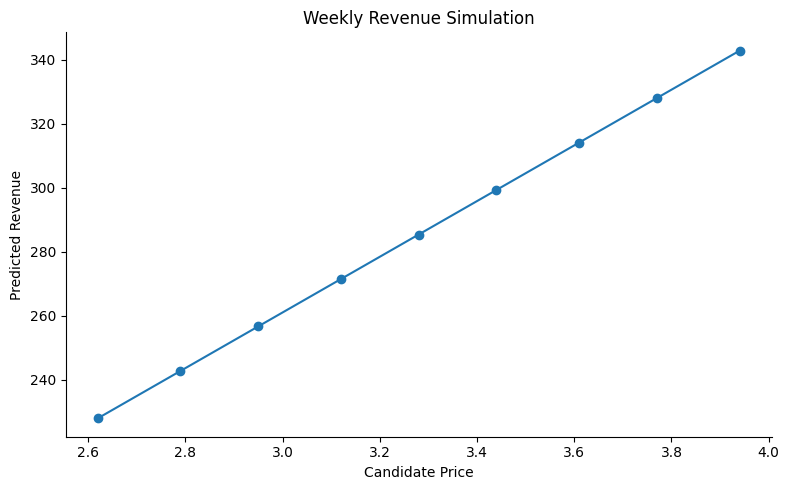

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    sim_week["candidate_price"],
    sim_week["predicted_revenue"],
    marker="o"
)

ax.set_xlabel("Candidate Price")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Weekly Revenue Simulation")

# remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# optional: keep clean grid
ax.grid(False)

plt.tight_layout()
plt.show()

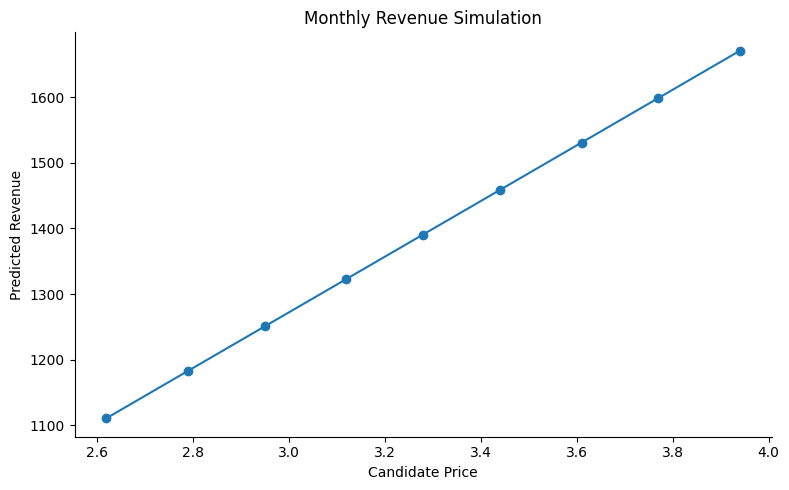

In [15]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    sim_month["candidate_price"],
    sim_month["predicted_revenue"],
    marker="o"
)

ax.set_xlabel("Candidate Price")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Monthly Revenue Simulation")

# remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# optional: keep clean grid
ax.grid(False)

plt.tight_layout()
plt.show()
